In [1]:
import pandas as pd
import json


In [2]:
df_pep = pd.read_csv(r"D:\BBB Trans AI\data\bbb_struct_subset_100.csv")
print(df_pep.shape)
df_pep.head()


(100, 5)


,ID,Sequence,BBB_label,BBB_prob,prob_bin
0,N_C233,HALAHKLKHLLHRLRHLLHRHLRHALAH,0,0.062,low
1,N_C93,YRWRCKNQN,0,0.044,low
2,N_C248,CAYGGQQGGQGGG,0,0.696,high
3,P_71,YTGFLSN,1,0.974,high
4,P_123,YGRKKRRQRRR,1,0.820,high


In [3]:
df_struct = pd.read_csv(r"D:\BBB Trans AI\features\bbb_struct_features_100.csv")
print(df_struct.shape)
df_struct.head()


(99, 9)


,ID,length,radius_gyration,compactness,frac_positive,frac_negative,net_charge,frac_hydrophobic,frac_aromatic
0,N_C108,12,8.590800,1.396843,0.750000,0.000000,9,0.166667,0.00
1,N_C11,20,9.416270,2.123983,0.150000,0.000000,3,0.650000,0.05
2,N_C112,24,11.112412,2.159747,0.416667,0.041667,9,0.250000,0.00
3,N_C115,8,6.535278,1.224125,0.500000,0.000000,4,0.500000,0.50
4,N_C123,15,10.281929,1.458870,0.266667,0.000000,4,0.466667,0.20


In [4]:
df_merged = df_pep.merge(df_struct, on="ID", how="inner")
print(df_merged.shape)
df_merged.head()


(99, 13)


,ID,Sequence,BBB_label,BBB_prob,prob_bin,length,radius_gyration,compactness,frac_positive,frac_negative,net_charge,frac_hydrophobic,frac_aromatic
0,N_C233,HALAHKLKHLLHRLRHLLHRHLRHALAH,0,0.062,low,28,12.270012,2.281986,0.535714,0.0,15,0.464286,0.000000
1,N_C93,YRWRCKNQN,0,0.044,low,9,6.228406,1.444993,0.333333,0.0,3,0.222222,0.222222
2,N_C248,CAYGGQQGGQGGG,0,0.696,high,13,6.286460,2.067937,0.000000,0.0,0,0.153846,0.076923
3,P_71,YTGFLSN,1,0.974,high,7,4.817456,1.453049,0.000000,0.0,0,0.428571,0.285714
4,P_123,YGRKKRRQRRR,1,0.820,high,11,8.286591,1.327446,0.727273,0.0,8,0.090909,0.090909


In [5]:
df_feat = pd.read_csv(r"D:\BBB Trans AI\features\bbb_all_features_11desc.csv")
print(df_feat.shape)
df_feat.head()


(538, 1134)


,ID,A,C,D,E,F,G,H,I,K,...,CHOC760101.lag3,BIGC670101.lag1,BIGC670101.lag2,BIGC670101.lag3,CHAM810101.lag1,CHAM810101.lag2,CHAM810101.lag3,DAYM780201.lag1,DAYM780201.lag2,DAYM780201.lag3
0,P_1,0.0,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.0,...,0.163399,0.933439,0.938734,0.280999,0.964580,1.636864,0.584594,0.809259,0.693818,0.913895
1,P_2,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,...,1.079102,1.007260,1.318813,1.007260,1.027014,1.279305,1.027014,1.531124,0.271084,1.531124
2,P_3,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,...,1.936292,1.404600,0.257148,1.775422,1.708487,0.353047,1.052744,1.266584,0.845771,0.265340
3,P_4,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.2,...,0.761516,1.624047,0.595490,0.856078,1.287744,0.757845,1.287744,1.722039,0.727748,0.464300
4,P_5,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.0,0.0,...,1.330664,1.693087,0.233578,1.262624,1.555693,0.221948,1.555693,1.646699,0.902200,0.353301


In [6]:
with open(r"D:\BBB Trans AI\models\bbb_rf_top200_features.json") as f:
    top200 = json.load(f)

len(top200), top200[:10]


(200,
 ['Pc1.Y',
  'secondarystruct.Tr2332',
  'Y',
  'hydrophobicity_FASG890101.Tr2332',
  'charge.G1',
  'secondarystruct.G1',
  'hydrophobicity_ARGP820101.G2',
  'solventaccess.G3',
  'charge.1.residue100',
  'normwaalsvolume.2.residue0'])

In [7]:
df_feat_top = df_feat[["ID"] + top200]
print(df_feat_top.shape)
df_feat_top.head()


(538, 201)


,ID,Pc1.Y,secondarystruct.Tr2332,Y,hydrophobicity_FASG890101.Tr2332,charge.G1,secondarystruct.G1,hydrophobicity_ARGP820101.G2,solventaccess.G3,charge.1.residue100,...,hydrophobicity_ARGP820101.2.residue100,hydrophobicity_PONP930101.2.residue50,CIDH920105.lag1_y,charge.3.residue25,hydrophobicity_PONP930101.3.residue0,CIDH920105.lag3_y,solventaccess.1.residue75,hydrophobicity_PONP930101.1.residue0,BHAR880101.lag2_y,hydrophobicity_ZIMJ680101.3.residue0
0,P_1,0.000000,0.00,0.0,0.25,0.2,0.4,0.6,0.6,100.0,...,100.0,40.0,0.319230,0.0,20.0,-0.638472,20.0,60.0,-0.361555,60.0
1,P_2,0.000000,0.00,0.0,0.50,0.0,0.2,0.0,0.6,0.0,...,0.0,40.0,-0.041326,0.0,80.0,-0.041326,40.0,20.0,-0.509790,20.0
2,P_3,1.033376,0.25,0.2,0.75,0.2,0.4,0.2,0.4,100.0,...,100.0,80.0,-0.343381,0.0,20.0,-0.586285,60.0,40.0,0.614864,20.0
3,P_4,1.081354,0.50,0.2,0.50,0.2,0.2,0.2,0.4,80.0,...,80.0,0.0,-1.060096,0.0,20.0,-0.677330,60.0,40.0,0.692248,20.0
4,P_5,0.913887,1.00,0.2,1.00,0.0,0.0,0.0,0.4,0.0,...,0.0,80.0,-1.025128,0.0,20.0,-0.658501,80.0,40.0,0.804160,20.0


In [8]:
df_final = df_merged.merge(df_feat_top, on="ID", how="inner")
print(df_final.shape)
df_final.head()


(99, 213)


,ID,Sequence,BBB_label,BBB_prob,prob_bin,length,radius_gyration,compactness,frac_positive,frac_negative,...,hydrophobicity_ARGP820101.2.residue100,hydrophobicity_PONP930101.2.residue50,CIDH920105.lag1_y,charge.3.residue25,hydrophobicity_PONP930101.3.residue0,CIDH920105.lag3_y,solventaccess.1.residue75,hydrophobicity_PONP930101.1.residue0,BHAR880101.lag2_y,hydrophobicity_ZIMJ680101.3.residue0
0,N_C233,HALAHKLKHLLHRLRHLLHRHLRHALAH,0,0.062,low,28,12.270012,2.281986,0.535714,0.0,...,100.000000,53.571429,-0.277504,0.0,10.714286,-0.163648,64.285714,21.428571,0.162785,10.714286
1,N_C93,YRWRCKNQN,0,0.044,low,9,6.228406,1.444993,0.333333,0.0,...,66.666667,22.222222,-0.081474,0.0,11.111111,-0.333851,33.333333,66.666667,0.699213,11.111111
2,N_C248,CAYGGQQGGQGGG,0,0.696,high,13,6.286460,2.067937,0.000000,0.0,...,15.384615,61.538462,0.421055,0.0,7.692308,-0.095468,69.230769,46.153846,0.097678,23.076923
3,P_71,YTGFLSN,1,0.974,high,7,4.817456,1.453049,0.000000,0.0,...,0.000000,42.857143,-0.022688,0.0,14.285714,0.072897,57.142857,28.571429,-0.776310,14.285714
4,P_123,YGRKKRRQRRR,1,0.820,high,11,8.286591,1.327446,0.727273,0.0,...,100.000000,54.545455,-0.201859,0.0,9.090909,0.013227,18.181818,36.363636,-0.460725,9.090909


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Columns that are NOT features
non_feature_cols = ["ID", "Sequence", "BBB_label", "BBB_prob", "prob_bin"]

X = df_final.drop(columns=non_feature_cols)
y = df_final["BBB_label"]

print(X.shape, y.shape)


(99, 208) (99,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf_hybrid = RandomForestClassifier(
    n_estimators=500,
    n_jobs=-1,
    random_state=42,
)

rf_hybrid.fit(X_train, y_train)

y_pred  = rf_hybrid.predict(X_test)
y_proba = rf_hybrid.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.64      0.70      0.67        10

    accuracy                           0.65        20
   macro avg       0.65      0.65      0.65        20
weighted avg       0.65      0.65      0.65        20

AUC: 0.69


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_hybrid, X, y, cv=cv, scoring="roc_auc")

print("5-fold AUC:", cv_scores)
print("Mean AUC:", cv_scores.mean())
print("Std:", cv_scores.std())


5-fold AUC: [0.73       0.79       0.735      0.68       0.81666667]
Mean AUC: 0.7503333333333332
Std: 0.04810174402012654


In [12]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import json
import os

# 1. Train RF on all samples to get feature importances
rf_fs = RandomForestClassifier(
    n_estimators=1000,
    n_jobs=-1,
    random_state=42
)
rf_fs.fit(X, y)

# 2. Make a Series of importances
importances = pd.Series(rf_fs.feature_importances_, index=X.columns)

# 3. Pick top-k features (you can change 30 → 20 if you want even smaller)
TOP_K = 30
top_k_features = importances.sort_values(ascending=False).head(TOP_K).index.tolist()

print("Top-k feature count:", len(top_k_features))
print(top_k_features[:10])  # peek at first 10

# 4. Reduce X to these features
X_top = X[top_k_features]
print("X_top shape:", X_top.shape)

# 5. Save the feature list for later use (Streamlit app etc.)
os.makedirs(r"D:\BBB Trans AI\models", exist_ok=True)
with open(r"D:\BBB Trans AI\models\bbb_hybrid_top30_features.json", "w") as f:
    json.dump(top_k_features, f, indent=2)

print("Saved top-30 feature list to models folder.")


Top-k feature count: 30
['hydrophobicity_FASG890101.Tr2332', 'secondarystruct.G1', 'secondarystruct.1.residue0', 'hydrophobicity_FASG890101.1.residue75', 'secondarystruct.Tr2332', 'hydrophobicity_ARGP820101.G2', 'hydrophobicity_ARGP820101.3.residue75', 'CHOC760101.lag1_y', 'CHOC760101.lag1_x', 'polarity.3.residue75']
X_top shape: (99, 30)
Saved top-30 feature list to models folder.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf_hybrid_small = RandomForestClassifier(
    n_estimators=500,
    n_jobs=-1,
    random_state=42
)
rf_hybrid_small.fit(X_train, y_train)

y_pred  = rf_hybrid_small.predict(X_test)
y_proba = rf_hybrid_small.predict_proba(X_test)[:, 1]

print("=== RF (top-30) test set ===")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

# 5-fold CV AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_hybrid_small, X_top, y, cv=cv, scoring="roc_auc")

print("\n5-fold AUC:", cv_scores)
print("Mean AUC:", cv_scores.mean())
print("Std:", cv_scores.std())


=== RF (top-30) test set ===
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.64      0.70      0.67        10

    accuracy                           0.65        20
   macro avg       0.65      0.65      0.65        20
weighted avg       0.65      0.65      0.65        20

AUC: 0.74

5-fold AUC: [0.755 0.89  0.73  0.68  0.9  ]
Mean AUC: 0.791
Std: 0.08834025130143108


In [14]:
import joblib
import json
import os

os.makedirs("../models", exist_ok=True)

# ✅ Save the TRUE top-30 RF model
joblib.dump(rf_hybrid_small, "../models/bbb_rf_top30.pkl")

# ✅ Save the correct top-30 feature list
with open("../models/bbb_rf_top30_features.json", "w") as f:
    json.dump(list(top_k_features), f, indent=2)

print("Saved RF top-30 model + feature list!")


Saved RF top-30 model + feature list!


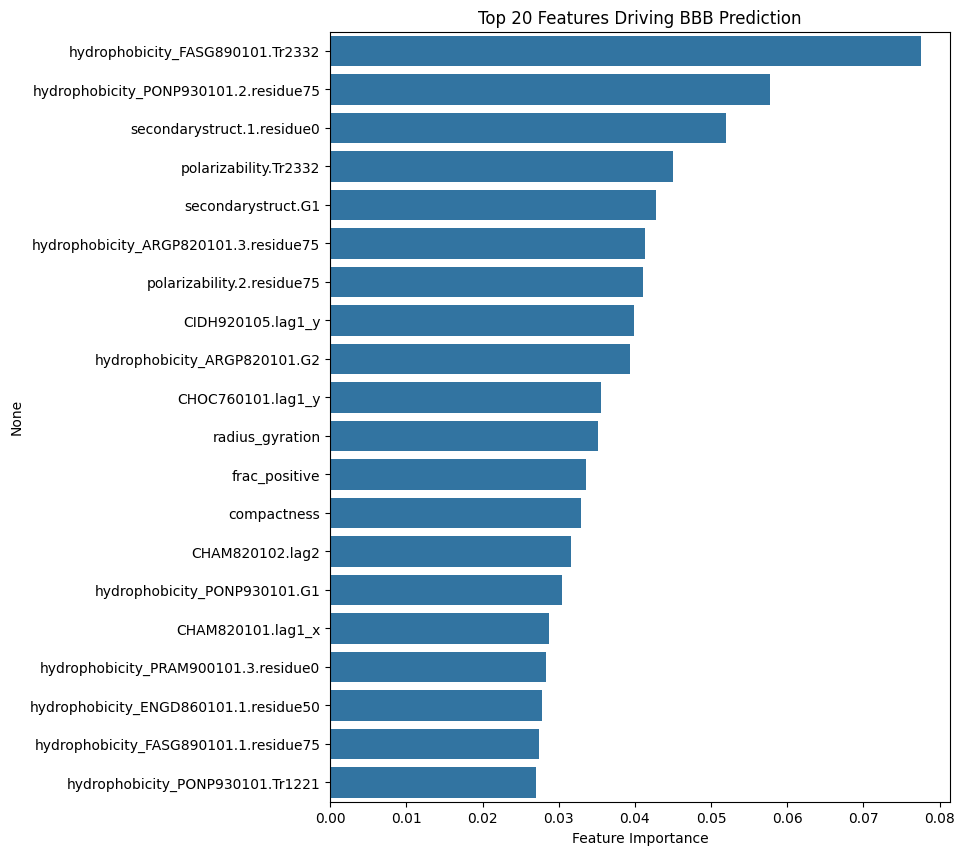

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(rf_hybrid_small.feature_importances_, index=X_top.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,10))
sns.barplot(x=top20.values, y=top20.index)
plt.xlabel("Feature Importance")
plt.title("Top 20 Features Driving BBB Prediction")
plt.savefig("Top 20 Features Driving BBB Prediction.png", dpi=300, bbox_inches="tight")
plt.show()


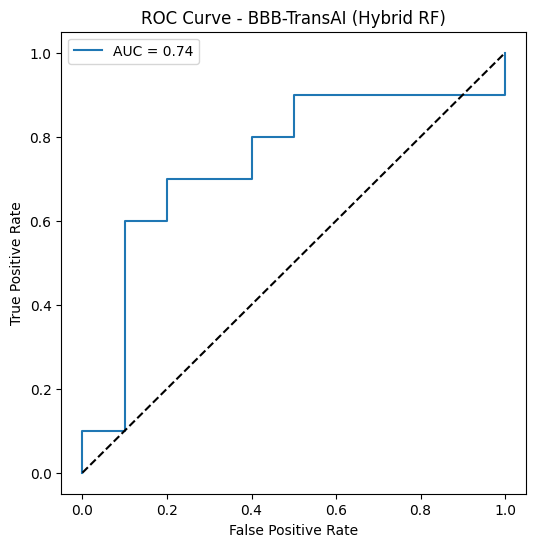

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BBB-TransAI (Hybrid RF)")
plt.legend()
plt.show()


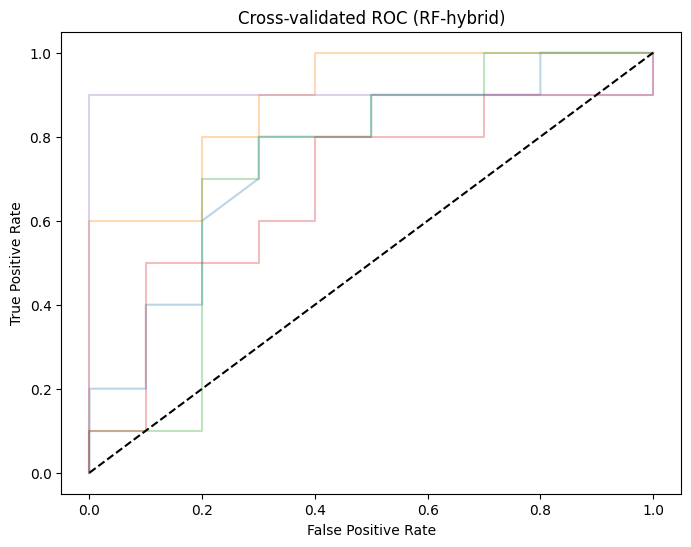

CV AUC: [0.7550000000000001, 0.89, 0.73, 0.68, 0.9] Mean: 0.791


In [19]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
mean_fpr = np.linspace(0, 1, 100)
aucs = []

plt.figure(figsize=(8,6))

for train_idx, test_idx in cv.split(X_top, y):
    X_train, X_test = X_top.iloc[train_idx], X_top.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_hybrid_small.fit(X_train, y_train)
    y_proba = rf_hybrid_small.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y[test_idx], y_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, alpha=0.3)

plt.plot([0,1], [0,1], 'k--')
plt.title("Cross-validated ROC (RF-hybrid)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("CV AUC:", aucs, "Mean:", np.mean(aucs))


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Make sure X_top is a DataFrame and y is a Series
print(type(X_top), type(y))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))

for fold, (train_idx, test_idx) in enumerate(cv.split(X_top, y), 1):
    # ✅ use iloc to index by row position
    X_train, X_test = X_top.iloc[train_idx], X_top.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_hybrid.fit(X_train, y_train)
    y_proba = rf_hybrid.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # interpolate TPR on common FPR grid for mean curve
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {fold} (AUC = {roc_auc:.2f})")

# Mean ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(
    mean_fpr,
    mean_tpr,
    color="blue",
    label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})",
    lw=2,
)

# Chance line
plt.plot([0, 1], [0, 1], "k--", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-validated ROC – BBB-TransAI (Hybrid RF, top-30)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_hybrid_rf_top30.png", dpi=300, bbox_inches="tight")
plt.show()


print("Fold AUCs:", aucs)
print("Mean AUC:", mean_auc)
print("Std AUC:", std_auc)


In [ ]:
# already run earlier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, stratify=y, random_state=42
)

rf_hybrid.fit(X_train, y_train)   # RF model on top-30 features


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class
y_scores = rf_hybrid.predict_proba(X_test)[:, 1]

# Compute Precision–Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Average precision (area under PR curve)
ap = average_precision_score(y_test, y_scores)
print("Average Precision (AP):", ap)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"RF (AP = {ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – BBB-TransAI (Hybrid RF, top-30)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("pr_curve_hybrid_rf_top30.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# X_top has only the selected top-30 features
corr = X_top.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False)
plt.title("Correlation Heatmap – Top-30 Features")
plt.tight_layout()
plt.savefig("corr_top30_features.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = df_final.copy()   # or your original df with Sequence + BBB_label
# If df_final doesn’t have BBB_label, use the dataset you used to train.

aas = list("ACDEFGHIKLMNPQRSTVWY")

def aa_freq(seqs):
    joined = "".join(seqs)
    total = len(joined)
    freq = {aa: joined.count(aa)/total for aa in aas}
    return pd.Series(freq)

comp_pos = aa_freq(df.loc[df["BBB_label"] == 1, "Sequence"])
comp_neg = aa_freq(df.loc[df["BBB_label"] == 0, "Sequence"])

comp_df = pd.DataFrame({"BBB+": comp_pos, "BBB-": comp_neg})
comp_df = comp_df.reindex(aas)

plt.figure(figsize=(10,4))
comp_df.plot(kind="bar", width=0.8)
plt.xlabel("Amino acid")
plt.ylabel("Fraction")
plt.title("Amino-acid Composition – BBB+ vs BBB− Peptides")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("aa_composition_bbb_pos_neg.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

struct_cols = ["radius_gyration", "compactness", "net_charge",
               "frac_hydrophobic", "frac_positive", "frac_negative"]

df_struct_plot = df_final.dropna(subset=struct_cols).copy()

for col in struct_cols:
    plt.figure(figsize=(4,4))
    sns.violinplot(data=df_struct_plot, x="BBB_label", y=col,
                   palette=["#9999ff", "#ff9999"])
    plt.xlabel("Class (0 = BBB-, 1 = BBB+)")
    plt.title(f"{col} distribution by BBB class")
    plt.tight_layout()
    plt.savefig(f"violin_{col}_bbb_class.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# X_top has only the selected top-30 features
corr = X_top.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Correlation Heatmap – Top-30 Features", fontsize=16)
plt.tight_layout()
plt.savefig("corr_top30_features_labeled.png", dpi=300)
plt.show()


In [ ]:
feature_names = df_feat.columns.tolist()
len(feature_names), feature_names[:20]


In [ ]:
with open("all_1134_features.txt", "w") as f:
    for feat in feature_names:
        f.write(feat + "\n")


In [ ]:
import json
import pandas as pd

# Load top-200 sequence features
with open("../models/bbb_rf_top200_features.json") as f:
    top200 = json.load(f)


In [ ]:
struct = pd.read_csv("../features/bbb_struct_features_100.csv")

# structural columns (excluding ID)
struct_features = [col for col in struct.columns if col != "ID"]


In [ ]:
hybrid_features = top200 + struct_features
print("Number of hybrid features:", len(hybrid_features))
print(hybrid_features)


In [ ]:
# Save all 208 feature names to a text file
with open("hybrid_208_features.txt", "w") as f:
    for feat in hybrid_features:
        f.write(feat + "\n")

print("Saved as hybrid_208_features.txt")


In [ ]:
top30_features


In [ ]:
# Save top-30 features to a text file
with open("top30_features.txt", "w") as f:
    for feat in top30_features:
        f.write(str(feat) + "\n")

print("Saved: top30_features.txt")


In [ ]:
import pandas as pd
import json
import os

os.makedirs("./feature_lists", exist_ok=True)  # folder to save outputs

AAS = set("ACDEFGHIKLMNPQRSTVWY")

def get_descriptor_family(name: str) -> str:
    # 1. AAC – single letter amino acid
    if len(name) == 1 and name in AAS:
        return "AAC"

    # 2. DPC – dipeptide composition (two AA letters)
    if len(name) == 2 and all(c in AAS for c in name):
        return "DPC"

    # 3. Pc1 / Pc2 families
    if name.startswith("Pc1."):
        return "Pc1 (position-based)"
    if name.startswith("Pc2."):
        return "Pc2 (hydrophobicity/hydrophilicity)"

    # 4. G-gap descriptors like g1.g1.g1
    if name.startswith("g") and "." in name and name[1].isdigit():
        return "G-gap dipeptide"

    # 5. Structural features
    if name in [
        "length",
        "radius_gyration",
        "compactness",
        "frac_positive",
        "frac_negative",
        "net_charge",
        "frac_hydrophobic",
        "frac_aromatic",
    ]:
        return "Structural"

    # 6. CTD & AAindex-style property descriptors
    if any(prefix in name for prefix in [
        "hydrophobicity_", "polarity.", "secondarystruct.",
        "solventaccess.", "charge.", "normwaalsvolume."
    ]):
        if ".residue" in name:
            return "CTDD (Distribution)"
        if "Tr" in name:
            return "CTDT (Transition)"
        if ".G1" in name or ".G2" in name or ".G3" in name:
            return "CTDC (Composition)"
        return "AAindex / property-based"

    # 7. Autocorrelation: Moran / Geary / Moreau–Broto
    if ".lag1" in name or ".lag2" in name or ".lag3" in name:
        return "Autocorrelation"

    # 8. Fallback
    return "Other / AAindex"


In [ ]:
feat = pd.read_csv("../features/bbb_all_features_11desc.csv")

all_features = [c for c in feat.columns if c != "ID"]

df_all = pd.DataFrame({"feature": all_features})
df_all["family"] = df_all["feature"].apply(get_descriptor_family)

# Save
df_all.to_csv("./feature_lists/all_1134_features_with_families.csv", index=False)
df_all.to_csv("./feature_lists/all_1134_features_with_families.txt",
              index=False, sep="\t")

print("Saved: all_1134_features_with_families.csv and .txt")


In [ ]:
with open("../models/bbb_rf_top200_features.json") as f:
    top200 = json.load(f)

df_top200 = pd.DataFrame({"feature": top200})
df_top200["family"] = df_top200["feature"].apply(get_descriptor_family)

df_top200.to_csv("./feature_lists/top200_sequence_features_with_families.csv",
                index=False)
df_top200.to_csv("./feature_lists/top200_sequence_features_with_families.txt",
                index=False, sep="\t")

print("Saved: top200_sequence_features_with_families.csv and .txt")


In [ ]:
# structural feature names
struct = pd.read_csv("../features/bbb_struct_features_100.csv")
struct_features = [c for c in struct.columns if c != "ID"]

# hybrid = unique order-preserving combination of top200 + structural
from collections import OrderedDict
hybrid_features = list(OrderedDict.fromkeys(top200 + struct_features))

print("Hybrid feature count:", len(hybrid_features))  # should be 208

df_hybrid = pd.DataFrame({"feature": hybrid_features})
df_hybrid["family"] = df_hybrid["feature"].apply(get_descriptor_family)

df_hybrid.to_csv("./feature_lists/hybrid_208_features_with_families.csv",
                 index=False)
df_hybrid.to_csv("./feature_lists/hybrid_208_features_with_families.txt",
                 index=False, sep="\t")

print("Saved: hybrid_208_features_with_families.csv and .txt")


In [ ]:
with open("../models/bbb_rf_top30_features.json") as f:
    top30 = json.load(f)

df_top30 = pd.DataFrame({"feature": top30})
df_top30["family"] = df_top30["feature"].apply(get_descriptor_family)

df_top30.to_csv("./feature_lists/hybrid_top30_features_with_families.csv",
                index=False)
df_top30.to_csv("./feature_lists/hybrid_top30_features_with_families.txt",
                index=False, sep="\t")

print("Saved: hybrid_top30_features_with_families.csv and .txt")


In [ ]:
df_all   # contains columns: ["feature", "family"]


In [ ]:
unique_families = df_all["family"].unique()
for fam in unique_families:
    print(fam)


In [ ]:
family_counts = df_all["family"].value_counts()

print(family_counts)


In [ ]:
family_counts.to_csv("descriptor_family_counts.csv")
print("Saved descriptor_family_counts.csv")
